# W-State Swap-Free Routing via Best CZ Chain

The W-state F-gate circuit has a **linear interaction graph** — every 2-qubit gate acts between consecutive logical qubits (q0-q1, q1-q2, …).  
If we map those logical qubits to a **hardware path** of the same length, no SWAP gates are ever needed.

**Strategy:**
1. Load live CZ gate fidelities and readout fidelities from calibration data  
2. Visualise the hardware topology coloured by gate quality  
3. Run a **beam search** over all simple paths of length N, scoring by product of CZ fidelities × readout fidelities  
4. Map the W-state circuit onto that path — transpile with `routing_method='none'` and verify 0 SWAPs  
5. Run and analyse results

In [1]:
N_QUBITS    = 10    # W-state size (keep ≤ 20 for a hardware path to exist)
SHOTS       = 200
BEAM_WIDTH  = 100   # beam search width — higher = better quality, slower

## 1. Connect to IQM Resonance

In [2]:
import os
from pathlib import Path
from iqm.qiskit_iqm import IQMProvider

secret_path = Path().cwd() / ".secrets" / "iqm_api_key"
api_token = secret_path.read_text().strip() if secret_path.exists() \
            else input("IQM Resonance API token: ").strip()
os.environ["IQM_TOKEN"] = api_token

provider = IQMProvider("https://resonance.meetiqm.com", quantum_computer="emerald")
backend  = provider.get_backend()
print(f"Connected to: {backend.name}  ({backend.num_qubits} qubits)")

d:\Documents\ETH QHackathon\iqm_qte\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Connected to: IQMBackend  (54 qubits)


## 2. Load calibration data

`CalibrationDataManager` returns live per-edge CZ fidelities and per-qubit readout fidelities from the backend.  
Keys are qubit name strings: CZ uses `"['QB1', 'QB2']"`, readout uses `"QB1"`.

In [3]:
from iqm.qubit_selector.qubit_selector import CalibrationDataManager

cal = CalibrationDataManager().get_calibration_fidelities(backend)

# CZ fidelity per ordered qubit pair, keyed by string repr of list e.g. "['QB1', 'QB2']"
cz_raw      = cal.get("CZ", {})
readout_raw = cal.get("readout", {})

# Build lookup: frozenset of physical qubit indices → CZ fidelity
cz_fid = {}
for key_str, fid in cz_raw.items():
    try:
        names = eval(key_str)          # e.g. ['QB1', 'QB2']
        idxs  = tuple(backend.qubit_name_to_index(n) for n in names)
        cz_fid[frozenset(idxs)] = float(fid)
    except Exception:
        pass

# Build lookup: physical qubit index → readout fidelity
ro_fid = {}
for name, fid in readout_raw.items():
    try:
        ro_fid[backend.qubit_name_to_index(name)] = float(fid)
    except Exception:
        pass

print(f"CZ fidelities loaded:      {len(cz_fid)} edges")
print(f"Readout fidelities loaded: {len(ro_fid)} qubits")
if cz_fid:
    vals = list(cz_fid.values())
    print(f"CZ fidelity  min={min(vals):.4f}  mean={sum(vals)/len(vals):.4f}  max={max(vals):.4f}")
if ro_fid:
    vals = list(ro_fid.values())
    print(f"Readout fid  min={min(vals):.4f}  mean={sum(vals)/len(vals):.4f}  max={max(vals):.4f}")

CZ fidelities loaded:      81 edges
Readout fidelities loaded: 54 qubits
CZ fidelity  min=0.8802  mean=0.9858  max=0.9987
Readout fid  min=0.7924  mean=0.9744  max=0.9936


## 3. Topology grid + calibration heatmap

Edges coloured by CZ fidelity, nodes by readout fidelity — so you can see at a glance which regions of the chip are highest quality.

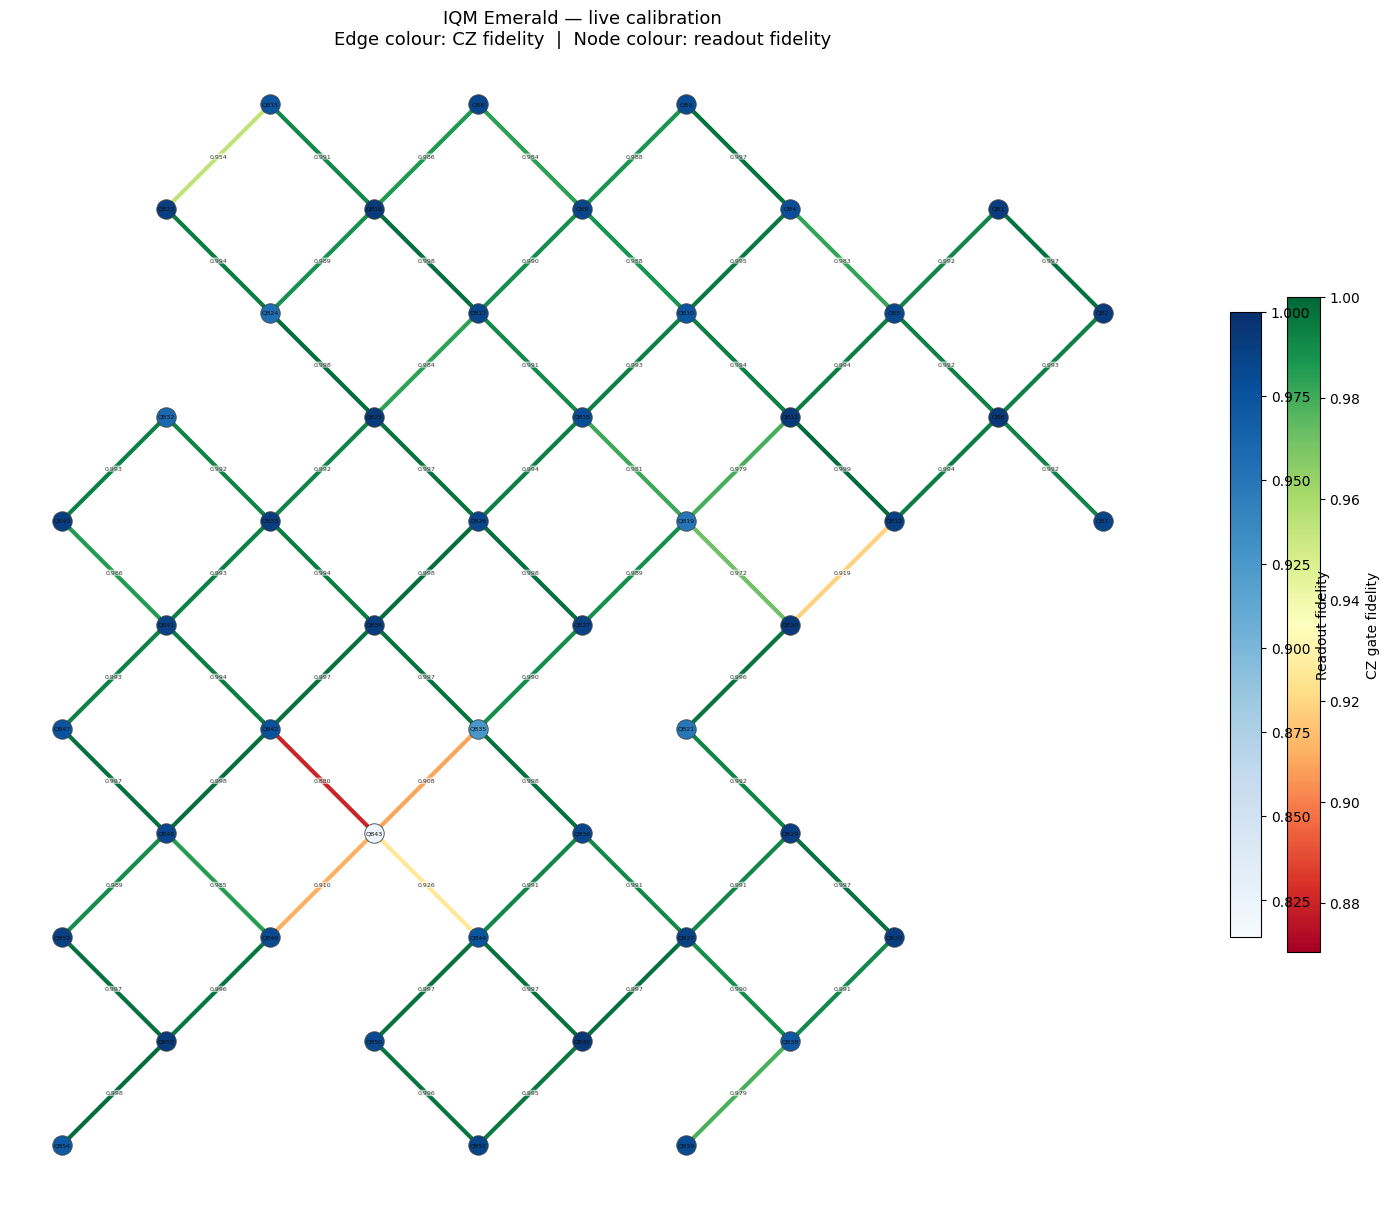

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors
import matplotlib.patches as mpatches
from collections import deque

# ── BFS grid layout (same helper used throughout) ─────────────────────────
def build_grid(coupling_map):
    edges_list = list(coupling_map.get_edges())
    adj = {}
    for u, v in edges_list:
        adj.setdefault(u, set()).add(v)
        adj.setdefault(v, set()).add(u)
    corner = min(adj, key=lambda q: len(adj[q]))
    nbrs   = sorted(adj[corner])
    coords = {corner: (0, 0)}; used = {(0, 0)}
    coords[nbrs[0]] = (1, 0); used.add((1, 0))
    if len(nbrs) > 1:
        coords[nbrs[1]] = (0, 1); used.add((0, 1))
    queue = deque(coords.keys())
    offs  = [(1,0),(-1,0),(0,1),(0,-1)]
    while queue:
        node = queue.popleft(); x, y = coords[node]
        for nb in adj[node]:
            if nb in coords: continue
            placed = [n2 for n2 in adj[nb] if n2 in coords]
            for dx, dy in offs:
                p = (x+dx, y+dy)
                if p in used: continue
                if all(abs(p[0]-coords[n2][0])+abs(p[1]-coords[n2][1])==1 for n2 in placed):
                    coords[nb] = p; used.add(p); queue.append(nb); break
    return adj, {q: (float(gx-gy), float(gx+gy)) for q, (gx,gy) in coords.items()}

adj, disp = build_grid(backend.coupling_map)
all_edges  = list(backend.coupling_map.get_edges())

# ── Colormaps ──────────────────────────────────────────────────────────────
cz_vals  = [cz_fid.get(frozenset((u,v)), 0.9) for u,v in all_edges]
ro_vals  = [ro_fid.get(q, 0.9) for q in disp]

cz_norm  = mcolors.Normalize(vmin=max(0.8, min(cz_vals)-0.01), vmax=1.0)
ro_norm  = mcolors.Normalize(vmin=max(0.8, min(ro_vals)-0.01), vmax=1.0)
cz_cmap  = cm.RdYlGn
ro_cmap  = cm.Blues

fig, ax = plt.subplots(figsize=(14, 14))
ax.set_aspect("equal")

# Draw edges
drawn = set()
for u, v in all_edges:
    key = frozenset((u, v))
    if key in drawn or u not in disp or v not in disp: continue
    drawn.add(key)
    fid   = cz_fid.get(key, 0.9)
    x0,y0 = disp[u]; x1,y1 = disp[v]
    ax.plot([x0,x1],[y0,y1], color=cz_cmap(cz_norm(fid)), lw=3, zorder=1, solid_capstyle="round")
    xm,ym = (x0+x1)/2, (y0+y1)/2
    ax.text(xm, ym, f"{fid:.3f}", ha="center", va="center",
            fontsize=4.5, color="#333333", zorder=3,
            bbox=dict(boxstyle="round,pad=0.1", fc="white", alpha=0.6, ec="none"))

# Draw nodes
for phys, (px, py) in disp.items():
    fid   = ro_fid.get(phys, 0.9)
    color = ro_cmap(ro_norm(fid))
    ax.plot(px, py, "o", markersize=14, color=color,
            markeredgecolor="#444", markeredgewidth=0.6, zorder=4)
    ax.text(px, py, backend.index_to_qubit_name(phys),
            ha="center", va="center", fontsize=4.5, color="#111", zorder=5)

# Colorbars
sm_cz = cm.ScalarMappable(cmap=cz_cmap, norm=cz_norm)
sm_ro = cm.ScalarMappable(cmap=ro_cmap, norm=ro_norm)
cb1 = plt.colorbar(sm_cz, ax=ax, fraction=0.025, pad=0.02)
cb1.set_label("CZ gate fidelity", fontsize=10)
cb2 = plt.colorbar(sm_ro, ax=ax, fraction=0.025, pad=0.06)
cb2.set_label("Readout fidelity", fontsize=10)

ax.set_title("IQM Emerald — live calibration\nEdge colour: CZ fidelity  |  Node colour: readout fidelity", fontsize=13)
ax.axis("off")
plt.tight_layout()
plt.show()

## 4. Find best chain — beam search

Score each path of length N by the **product of CZ fidelities** along its edges × **product of readout fidelities** of its qubits (computed in log-space to avoid underflow).  
Beam search keeps the top-`BEAM_WIDTH` partial paths at every extension step.

In [5]:
import math

def beam_search_chain(n, adj, cz_fid, ro_fid, beam_width, default_cz=0.90, default_ro=0.95):
    """
    Find the best hardware path of length n using beam search.
    Score = sum of log(CZ fidelity per edge) + sum of log(readout fidelity per qubit).
    Returns (best_path, score_as_product) where best_path is ordered [phys_q0, ..., phys_q_{n-1}].
    """
    def log_safe(x):
        return math.log(max(x, 1e-12))

    # Initialise beam: one entry per qubit
    # State: (log_score, path_list)
    beam = []
    for q in adj:
        beam.append((log_safe(ro_fid.get(q, default_ro)), [q]))
    beam.sort(reverse=True)
    beam = beam[:beam_width]

    for _ in range(n - 1):
        candidates = []
        for log_score, path in beam:
            last = path[-1]
            used = set(path)
            for nbr in adj[last]:
                if nbr in used:
                    continue
                edge_log = log_safe(cz_fid.get(frozenset((last, nbr)), default_cz))
                node_log = log_safe(ro_fid.get(nbr, default_ro))
                candidates.append((log_score + edge_log + node_log, path + [nbr]))
        if not candidates:
            break
        candidates.sort(reverse=True)
        beam = candidates[:beam_width]

    complete = [(s, p) for s, p in beam if len(p) == n]
    if not complete:
        raise RuntimeError(f"No complete chain of length {n} found — try reducing N_QUBITS or increasing BEAM_WIDTH")

    best_log, best_path = complete[0]
    return best_path, math.exp(best_log)


best_chain, chain_score = beam_search_chain(N_QUBITS, adj, cz_fid, ro_fid, BEAM_WIDTH)
best_names = [backend.index_to_qubit_name(q) for q in best_chain]

print(f"Best chain of {N_QUBITS} qubits (log-product score = {chain_score:.6f}):")
for i, (phys, name) in enumerate(zip(best_chain, best_names)):
    cz = cz_fid.get(frozenset((best_chain[i], best_chain[i+1])), None) if i < N_QUBITS-1 else None
    ro = ro_fid.get(phys, None)
    cz_str = f"  →CZ={cz:.4f}" if cz else ""
    print(f"  q{i:2d}  {name:6s}  readout={ro:.4f}{cz_str}")

Best chain of 10 qubits (log-product score = 0.845861):
  q 0  QB1     readout=0.9912  →CZ=0.9973
  q 1  QB2     readout=0.9917  →CZ=0.9930
  q 2  QB6     readout=0.9936  →CZ=0.9940
  q 3  QB12    readout=0.9891  →CZ=0.9987
  q 4  QB11    readout=0.9922  →CZ=0.9938
  q 5  QB10    readout=0.9735  →CZ=0.9934
  q 6  QB18    readout=0.9797  →CZ=0.9939
  q 7  QB26    readout=0.9848  →CZ=0.9984
  q 8  QB34    readout=0.9912  →CZ=0.9941
  q 9  QB33    readout=0.9903


## 5. Visualise chosen chain on topology

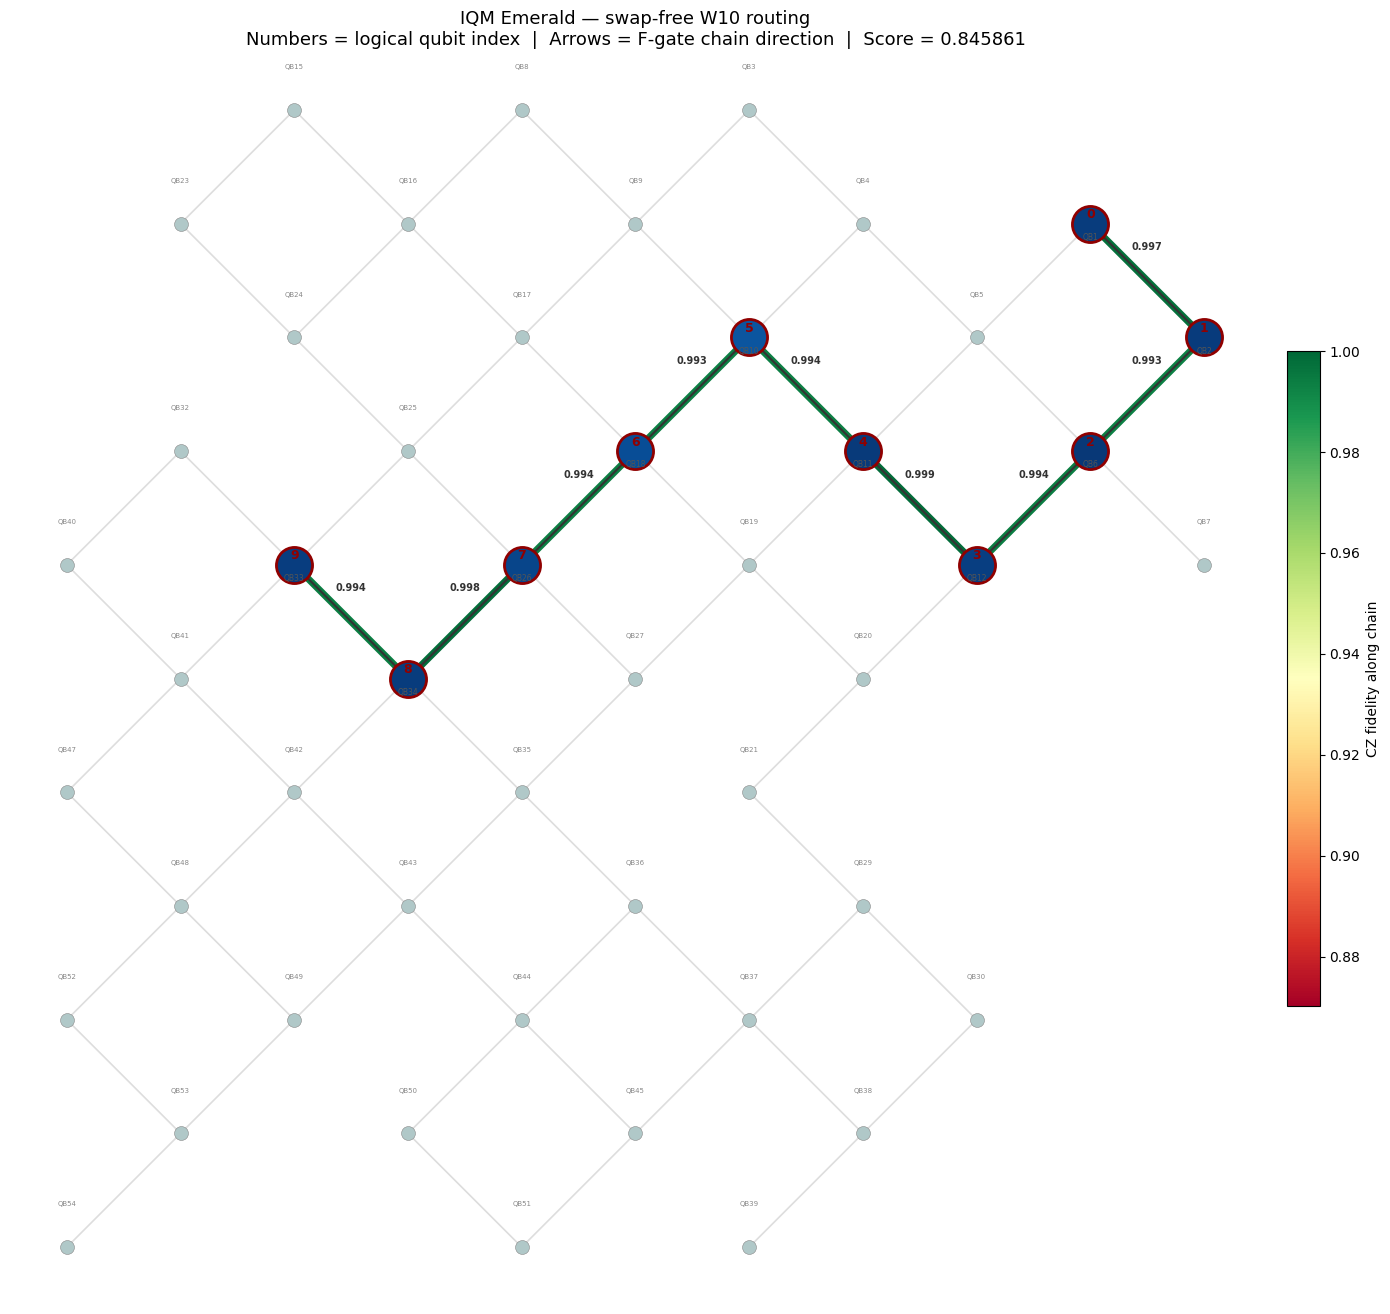

In [6]:
selected_set    = set(best_chain)
chain_pairs     = [(best_chain[i], best_chain[i+1]) for i in range(N_QUBITS-1)]
chain_set       = {frozenset(p) for p in chain_pairs}
phys_to_logical = {p: i for i, p in enumerate(best_chain)}

fig, ax = plt.subplots(figsize=(14, 14))
ax.set_aspect("equal")

# Background edges — greyed out
drawn = set()
for u, v in all_edges:
    key = frozenset((u, v))
    if key in drawn or key in chain_set: continue
    drawn.add(key)
    if u in disp and v in disp:
        x0,y0=disp[u]; x1,y1=disp[v]
        ax.plot([x0,x1],[y0,y1], color="#dddddd", lw=1.2, zorder=1)

# Chain edges — coloured by CZ fidelity + arrow
for pa, pb in chain_pairs:
    fid   = cz_fid.get(frozenset((pa,pb)), 0.9)
    color = cz_cmap(cz_norm(fid))
    x0,y0=disp[pa]; x1,y1=disp[pb]
    ax.plot([x0,x1],[y0,y1], color=color, lw=5, zorder=3, solid_capstyle="round")
    ax.annotate("", xy=(x1,y1), xytext=(x0,y0),
                arrowprops=dict(arrowstyle="-|>", color="#333333", lw=1.5, mutation_scale=16), zorder=4)
    xm,ym = (x0+x1)/2,(y0+y1)/2
    ax.text(xm, ym+0.25, f"{fid:.3f}", ha="center", va="bottom",
            fontsize=7, fontweight="bold", color="#333", zorder=5)

# Unselected nodes
for phys, (px, py) in disp.items():
    if phys in selected_set: continue
    ax.plot(px, py, "o", markersize=10, color="#b0c8c8",
            markeredgecolor="#888", markeredgewidth=0.4, zorder=2)
    ax.text(px, py+0.35, backend.index_to_qubit_name(phys),
            ha="center", va="bottom", fontsize=5, color="#888", zorder=3)

# Selected nodes — logical index + QB name
for phys in best_chain:
    if phys not in disp: continue
    px, py = disp[phys]
    log    = phys_to_logical[phys]
    ro     = ro_fid.get(phys, 0.9)
    node_color = ro_cmap(ro_norm(ro))
    ax.plot(px, py, "o", markersize=26, color=node_color,
            markeredgecolor="#900000", markeredgewidth=2, zorder=6)
    ax.text(px, py+0.08, str(log), ha="center", va="center",
            fontsize=9, fontweight="bold", color="#900000", zorder=7)
    ax.text(px, py-0.08, backend.index_to_qubit_name(phys), ha="center", va="top",
            fontsize=5.5, color="#555", zorder=7)

sm_cz2 = cm.ScalarMappable(cmap=cz_cmap, norm=cz_norm)
cb = plt.colorbar(sm_cz2, ax=ax, fraction=0.025, pad=0.02)
cb.set_label("CZ fidelity along chain", fontsize=10)

ax.set_title(
    f"IQM Emerald — swap-free W{N_QUBITS} routing\n"
    f"Numbers = logical qubit index  |  Arrows = F-gate chain direction  |  Score = {chain_score:.6f}",
    fontsize=13)
ax.axis("off")
plt.tight_layout()
plt.show()

## 6. Build circuits and transpile with no routing

In [7]:
from qiskit import transpile
from iqm.qubit_selector.qiskit_utils import get_circuit, CircuitType

qc_z = get_circuit(CircuitType.WSTATE, N_QUBITS); qc_z.measure_all()
qc_x = get_circuit(CircuitType.WSTATE, N_QUBITS)
qc_x.h(range(N_QUBITS)); qc_x.measure_all()

# routing_method='none' tells Qiskit to skip SWAP insertion entirely.
# This will FAIL if any 2-qubit gate is between non-adjacent hardware qubits —
# which is our guarantee: best_chain is a hardware path.
qc_z_t = transpile(qc_z, backend=backend, initial_layout=best_chain,
                   routing_method="none", optimization_level=1)
qc_x_t = transpile(qc_x, backend=backend, initial_layout=best_chain,
                   routing_method="none", optimization_level=1)

def swap_count(qc):
    return qc.count_ops().get("swap", 0)

print(f"Z-basis depth: {qc_z_t.depth()}   SWAPs: {swap_count(qc_z_t)}")
print(f"X-basis depth: {qc_x_t.depth()}   SWAPs: {swap_count(qc_x_t)}")
assert swap_count(qc_z_t) == 0 and swap_count(qc_x_t) == 0, "Unexpected SWAPs!"
print("✓ Zero SWAPs confirmed")

Z-basis depth: 24   SWAPs: 0
X-basis depth: 25   SWAPs: 0
✓ Zero SWAPs confirmed


## 7. Run, retrieve, and analyse

In [8]:
print(f"Submitting {SHOTS} shots × 2 circuits  (N={N_QUBITS}, 0 SWAPs)...")
job_z = backend.run(qc_z_t, shots=SHOTS)
job_x = backend.run(qc_x_t, shots=SHOTS)
print(f"Z-basis job: {job_z.job_id()}")
print(f"X-basis job: {job_x.job_id()}")

Submitting 200 shots × 2 circuits  (N=10, 0 SWAPs)...
Z-basis job: 019e0cd1-fb30-76f0-ab6b-768152d8b093
X-basis job: 019e0cd1-fe05-75d3-abf0-ddde739ea2c9


In [9]:
counts_z = job_z.result().get_counts()
counts_x = job_x.result().get_counts()
print("Z-basis counts:", counts_z)
print("X-basis counts:", counts_x)

[05-09 14:59:10;I] Waiting for job 019e0cd1-fb30-76f0-ab6b-768152d8b093 to finish...
[05-09 14:59:12;I] Waiting for job 019e0cd1-fe05-75d3-abf0-ddde739ea2c9 to finish...
Z-basis counts: {'0001000000 0001000000': 30, '0000000001 0000000001': 15, '0000100000 0000100000': 11, '0011001000 0011001000': 2, '0000001010 0000001010': 1, '0100000000 0100000000': 17, '0010000000 0010000000': 16, '0000011001 0000011001': 1, '0000010000 0000010000': 10, '0000000111 0000000111': 2, '0001100000 0001100000': 2, '0000000000 0000100000': 2, '1000000000 1000000000': 10, '0000000000 0000000010': 1, '0000000100 0000000100': 8, '0000000010 0000000010': 8, '0011000000 0011000000': 3, '0100010000 0100010000': 1, '0000001110 0000001110': 1, '0000001000 0000001000': 3, '0010001000 0010001000': 2, '0000000000 0100000000': 3, '0111000100 0111000100': 1, '0000000000 0000000000': 6, '1000000010 1000000010': 1, '0011100000 0011100000': 1, '0001000100 0001000100': 1, '0110000000 1110000000': 1, '0011000000 0011100000

Z-basis W-state fidelity: 0.000  (ideal 1.000)


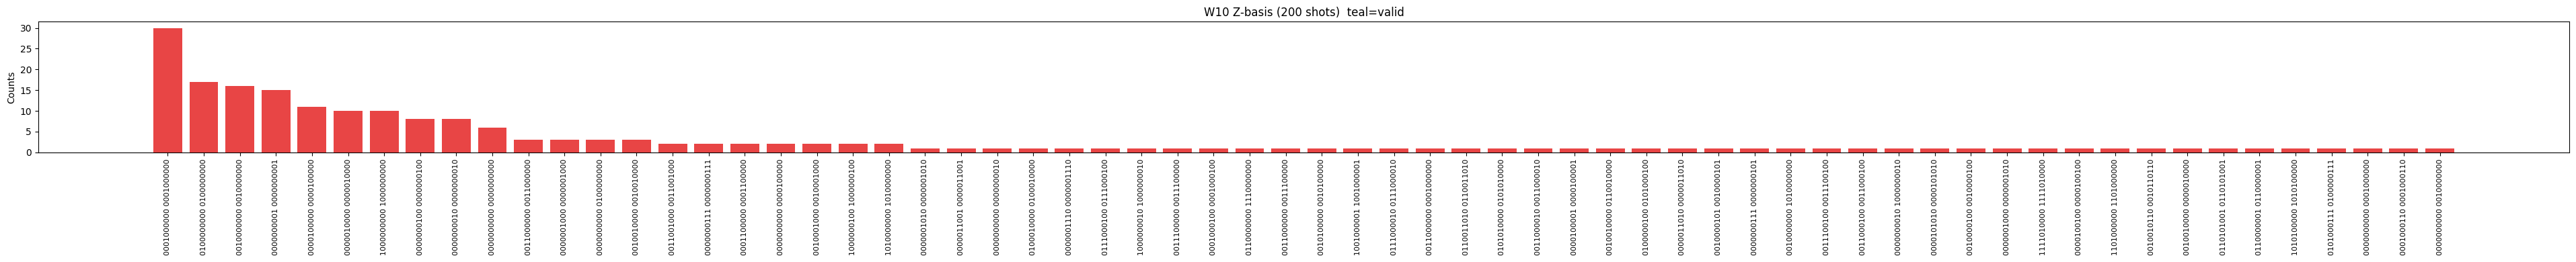


Entanglement witness W:
  Classical (separable): 0.0000
  Ideal W10:           0.2000
  Hardware (0-SWAP):     0.5504 ± 0.0153


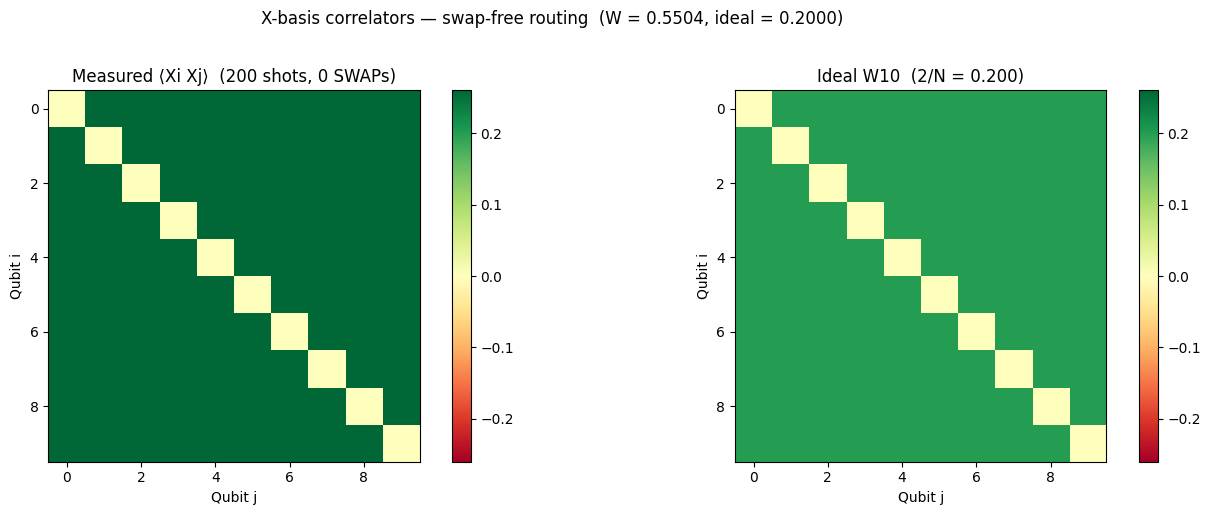

In [10]:
import matplotlib.pyplot as plt
import numpy as np

# ── Z-basis ────────────────────────────────────────────────────────────────
total_z      = sum(counts_z.values())
probs_z      = {k: v/total_z for k,v in counts_z.items()}
w_bitstrings = {format(1<<i, f"0{N_QUBITS}b") for i in range(N_QUBITS)}
fidelity_z   = sum(probs_z.get(s,0) for s in w_bitstrings)

print(f"Z-basis W-state fidelity: {fidelity_z:.3f}  (ideal 1.000)")
sorted_counts = sorted(counts_z.items(), key=lambda x:-x[1])
labels, vals  = zip(*sorted_counts)
colors = ["#32a8a4" if lb in w_bitstrings else "#e84545" for lb in labels]
fig, ax = plt.subplots(figsize=(max(8, len(labels)*0.6), 4))
ax.bar(range(len(labels)), vals, color=colors)
ax.set_xticks(range(len(labels)))
ax.set_xticklabels(labels, rotation=90, fontsize=8)
ax.set_ylabel("Counts"); ax.set_title(f"W{N_QUBITS} Z-basis ({SHOTS} shots)  teal=valid")
plt.tight_layout(); plt.show()

# ── X-basis correlators ────────────────────────────────────────────────────
total_x = sum(counts_x.values())
probs_x = {k: v/total_x for k,v in counts_x.items()}

def corr(probs, i, j):
    return sum((1-2*int(b[-(i+1)]))*(1-2*int(b[-(j+1)]))*p for b,p in probs.items())

C = np.array([[corr(probs_x,i,j) if i!=j else 0 for j in range(N_QUBITS)] for i in range(N_QUBITS)])
avg_corr    = C[np.triu_indices(N_QUBITS,k=1)].mean()
ideal_corr  = 2/N_QUBITS
shot_stderr = C[np.triu_indices(N_QUBITS,k=1)].std() / np.sqrt(N_QUBITS*(N_QUBITS-1)//2)

print(f"\nEntanglement witness W:")
print(f"  Classical (separable): 0.0000")
print(f"  Ideal W{N_QUBITS}:           {ideal_corr:.4f}")
print(f"  Hardware (0-SWAP):     {avg_corr:.4f} ± {shot_stderr:.4f}")

fig, axes = plt.subplots(1,2, figsize=(14,5))
vmax = max(ideal_corr*1.3, 0.01)
im1 = axes[0].imshow(C, cmap="RdYlGn", vmin=-vmax, vmax=vmax)
axes[0].set_title(f"Measured ⟨Xi Xj⟩  ({SHOTS} shots, 0 SWAPs)")
axes[0].set_xlabel("Qubit j"); axes[0].set_ylabel("Qubit i")
plt.colorbar(im1, ax=axes[0])
ideal_M = np.full((N_QUBITS,N_QUBITS), ideal_corr); np.fill_diagonal(ideal_M,0)
im2 = axes[1].imshow(ideal_M, cmap="RdYlGn", vmin=-vmax, vmax=vmax)
axes[1].set_title(f"Ideal W{N_QUBITS}  (2/N = {ideal_corr:.3f})")
axes[1].set_xlabel("Qubit j"); axes[1].set_ylabel("Qubit i")
plt.colorbar(im2, ax=axes[1])
plt.suptitle(f"X-basis correlators — swap-free routing  (W = {avg_corr:.4f}, ideal = {ideal_corr:.4f})", y=1.02)
plt.tight_layout(); plt.show()